<a href="https://colab.research.google.com/github/vyasamayuri/11239A102_opencv/blob/main/exp13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()
# Assuming only one file is uploaded, or you want to process the first one.
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}. Please ensure you are uploading a valid image file (e.g., .jpg, .png).")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Saving Screen Recording 2026-04-16 215234_000.jpg to Screen Recording 2026-04-16 215234_000.jpg


In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')


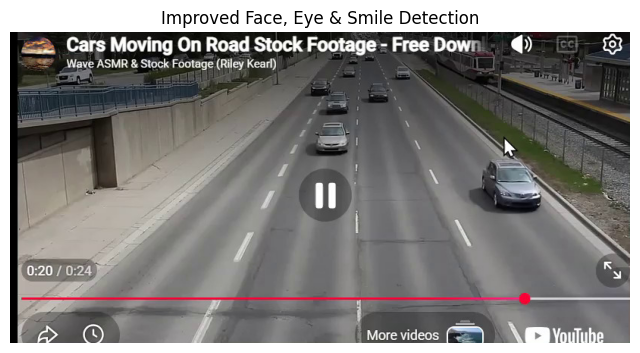

Faces detected: 0


In [ ]:
# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

result = img_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = result[y:y+h, x:x+w]

    # -----------------
    # Eye Detection (more relaxed)
    # -----------------
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20, 20)
    )

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # -----------------
    # Smile Detection (key fix here)
    # -----------------
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.3,
        minNeighbors=10,
         minSize=(25, 25)
    )

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

# Show result
plt.figure(figsize=(8,6))
plt.imshow(result)
plt.title("Improved Face, Eye & Smile Detection")
plt.axis('off')
plt.show()

print("Faces detected:", len(faces))

